## RAG LANGCHAIN

In [1]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("ollama:granite4.1:3b")

In [2]:
from langchain_core.documents import Document

# Read the files first
with open("./data/company_hr_policy.txt", "r", encoding="utf-8") as f:
    hr_text = f.read()

with open("./data/engineering_standards.txt", "r", encoding="utf-8") as f:
    eng_text = f.read()

with open("./data/onboarding_guide.txt", "r", encoding="utf-8") as f:
    onboard_text = f.read()

with open("./data/product_knowledge_base.txt", "r", encoding="utf-8") as f:
    product_text = f.read()


In [3]:
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings

def chunk_by_paragraph(file_path: str, collection_name: str, embedding_type: str = "huggingface"):
    # 1. Read file
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()

    # 2. Split into paragraphs
    paragraphs = text.strip().split("\n\n")
    docs = []
    for para in paragraphs:
        para = para.strip()
        if len(para) < 50:   # skip tiny fragments
            continue
        if para.startswith("=="):  # skip divider lines
            continue
        docs.append(Document(page_content=para, metadata={"source": file_path}))

    # 3. Choose embedding backend
    embeddings = OllamaEmbeddings(model="nomic-embed-text")

    # 4. Store in Chroma
    vectorstore = Chroma.from_documents(
        documents=docs,
        embedding=embeddings,
        collection_name=collection_name,
        persist_directory="./chroma_store"
    )

    return vectorstore, docs


In [4]:
hr_store = chunk_by_paragraph("./data/company_hr_policy.txt", "hr_policy")
eng_store = chunk_by_paragraph("./data/engineering_standards.txt", "engineering")
onboard_store = chunk_by_paragraph("./data/onboarding_guide.txt", "onboarding")
product_store = chunk_by_paragraph("./data/product_knowledge_base.txt", "product_kb")
security_policy = chunk_by_paragraph("./data/security_policy.txt", "security")


In [5]:
def retrieve_from_chroma(query: str, collection_name: str, k: int = 5):
    """
    Query a Chroma collection and return top-k relevant chunks.
    
    Args:
        query (str): The search query.
        collection_name (str): Name of the Chroma collection to query.
        embedding_type (str): 'huggingface' or 'ollama'.
        k (int): Number of results to return.
    """

    # Choose embedding backend
    
    embeddings = OllamaEmbeddings(model="nomic-embed-text")

    # Connect to existing Chroma collection
    vectorstore = Chroma(
        collection_name=collection_name,
        embedding_function=embeddings,
        persist_directory="./chroma_store"  
    )

    # Perform similarity search
    results = vectorstore.similarity_search(query, k=k)

    return results


In [6]:
from typing import TypedDict

class SupportState(TypedDict):
    question: str
    intent: str
    context: str
    answer: str
    source: str

In [7]:
from langchain.messages import SystemMessage, HumanMessage

def call_llm(sys_msg: str, human_msg: str):
    llm = init_chat_model("ollama:granite4.1:3b")
    messages = [
        SystemMessage(content=sys_msg),
        HumanMessage(content=human_msg)
    ]
    # print("DEBUG: Sending messages ->", messages)
    result = llm.invoke(messages)
    # print("DEBUG: LLM result ->", result)
    return result.content


In [8]:
# Node 1: Classify Intent
def classify_intent(state):
    """"Clasify the user's questions into one of ['hr','engineering','onboarding','product','security','general']"""
    question = state["question"]
    intent = call_llm(
        sys_msg= "You classify questions. Reply with excatly ONE word: ['hr','engineering','onboarding','product','security','general']",
        human_msg=f"Classify this question into excatly one category: ['hr','engineering','onboarding','product','security','general']/n/n Question: {question} \n\n Replay with  ONLY the category ['hr','engineering','onboarding','product','security','general']."
    )
    intent = intent.strip().lower()
    
    # ensure valid intent
    if intent not in ['hr','engineering','onboarding','product','security','general']:
        intent = 'general'
    print(f"[CLASSIFY] intent: {intent}")
    return {"intent": intent}

In [9]:
# Node 2a: handling hr questions

def search_hr_policy(state):
    """Answer hr-related question."""
    hr_results = retrieve_from_chroma(state["question"], "hr_policy")
    context = "\n\n".join(
    [f"{doc.metadata}:\n{doc.page_content}" for doc in hr_results]
    )
    print("[HR] Answered")
    return{"context": context, "source": "hr_policy"}

In [10]:
# Node 2b: handling engineering standards

def search_engineering_standards(state):
    """Answer engineering standards-related question."""
    engineering_results = retrieve_from_chroma(state["question"], "engineering")
    context = "\n\n".join(
    [f"{doc.metadata}:\n{doc.page_content}" for doc in engineering_results]
    )
    print("[ES] Answered")
    return{"context": context, "source": "engineering"}

In [11]:
# Node 2c: handling onboarding questions

def search_onboarding_guide(state):
    """Answer onboarding-related question."""
    onboarding_results = retrieve_from_chroma(state["question"], "onboarding")
    context = "\n\n".join(
    [f"{doc.metadata}:\n{doc.page_content}" for doc in onboarding_results]
    ) 
    print("[ONBOARDING] Answered")
    return{"context": context, "source": "onboarding"}

In [12]:
# Node 2d: handling product based questions

def search_product_knowledge_base(state):
    """Answer product-related question."""
    product_kb_results = retrieve_from_chroma(state["question"], "product_kb")
    context = "\n\n".join(
    [f"{doc.metadata}:\n{doc.page_content}" for doc in product_kb_results]
    ) 
    print("[PRODUCT KB] Answered")
    return{"context": context, "source": "product_kb"}

In [13]:
# Node 2e: handling security questions

def search_security_policy(state):
    """Answer security-related question."""
    security_results = retrieve_from_chroma(state["question"], "security")
    context = "\n\n".join(
    [f"{doc.metadata}:\n{doc.page_content}" for doc in security_results]
)
    print("[SECURITY] Answered")
    return{"context": context, "source": "security"}

In [14]:
# Node 3: generating answer

def generate_answer(state):
    """Generate answer from retrived context"""
    answer = call_llm(
        sys_msg=(
            "You are a helpful assistant. Use ONLY the provided context to answer. "
            "If the context contains relevant information, synthesize it into a complete answer. "
            "If the context is empty, respond 'No relevant context found.'"
        ),
        human_msg=f"Context:\n{state['context']}\n\nQuestion: {state['question']}\n\nAnswer:"
    )
    print(f" [GENERATE] answer ready.")
    return{"answer": answer}

In [15]:
# Node 4: handling general questions

def answer_general(state):
    """Answer general question."""
    answer = call_llm(
        sys_msg="You are a general company support agent. Answer questions about general queries.",
        human_msg=state["question"]
    )
    print("[GENERAL] Answered")
    return{"answer": answer, "source": "general_knowledge", "context": ""}

In [16]:
# ROUTING
def route(state):
    """Route based on Intent."""
    intent = state["intent"].strip().lower()
    if intent in ["hr", "engineering", "onboarding", "product", "security", "general"]:
        return intent
    return "general"


In [17]:
from langgraph.graph import StateGraph, START, END

# Build the graph
graph = StateGraph(SupportState)

# add nodes
graph.add_node("classify", classify_intent)
graph.add_node("hr_policy", search_hr_policy)
graph.add_node("engineering_standards", search_engineering_standards)
graph.add_node("onboarding_guide", search_onboarding_guide)
graph.add_node("product_knowledge", search_product_knowledge_base)
graph.add_node("security_policy", search_security_policy)
graph.add_node("answer_general", answer_general)
graph.add_node("generate", generate_answer)

# add edges
graph.add_edge(START, "classify")
graph.add_conditional_edges(
    "classify",
    route,
    {
        "hr": "hr_policy",
        "engineering": "engineering_standards",
        "onboarding": "onboarding_guide",
        "product": "product_knowledge",
        "security": "security_policy",
        "general": "answer_general",
    },
)

graph.add_edge("hr_policy", "generate")
graph.add_edge("engineering_standards", "generate")
graph.add_edge("onboarding_guide", "generate")
graph.add_edge("product_knowledge", "generate")
graph.add_edge("security_policy", "generate")

graph.add_edge("answer_general", END)
graph.add_edge("generate", END)

app = graph.compile()
print("Customer support router ready")


Customer support router ready


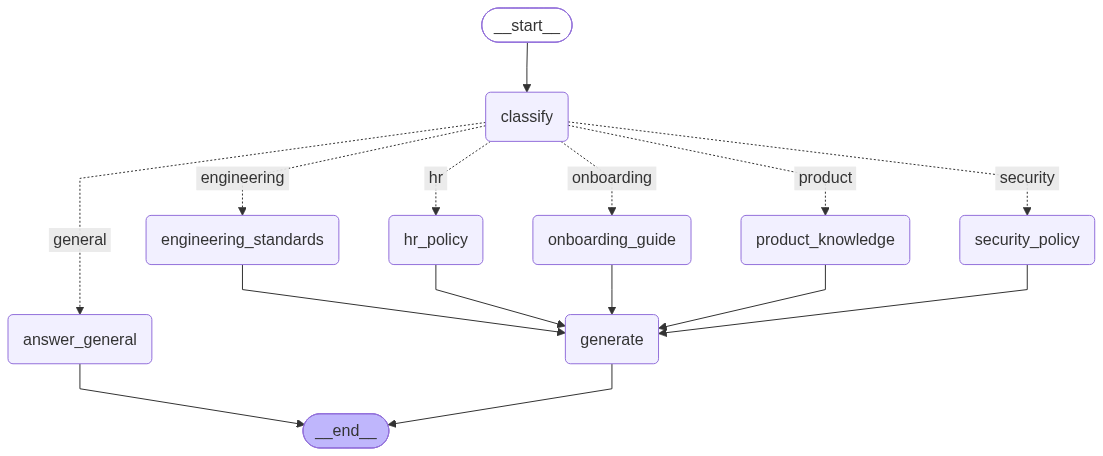

In [18]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
result = app.invoke({"question": "hr full remote policy"})
print(result['intent'])
print(result['answer'])

[CLASSIFY] intent: hr
[HR] Answered
 [GENERATE] answer ready.
hr
The HR full remote policy states that certain roles may be designated as fully remote, determined at the time of hiring and documented in the offer letter. Fully remote employees are required to visit the office at least once per quarter for team meetings and planning sessions.
